In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

#https://www.kaggle.com/datasets/tarekmasryo/football-matches-20242025-top-5-leagues/data
#Датасет футбольных матчей 2024/2025 сезона

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

print("Загрузка данных о футбольных матчах сезона 24/25")
df = pd.read_csv('football_matches_2024_2025.csv')

Загрузка данных о футбольных матчах сезона 24/25


In [28]:
#А
print("\nИнформация о датасете")
df.info()


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   competition_code  1941 non-null   object
 1   competition_name  1941 non-null   object
 2   season            1941 non-null   object
 3   match_id          1941 non-null   int64 
 4   matchday          1941 non-null   int64 
 5   stage             1941 non-null   object
 6   status            1941 non-null   object
 7   date_utc          1941 non-null   object
 8   referee           1941 non-null   object
 9   home_team_id      1941 non-null   int64 
 10  home_team         1941 non-null   object
 11  away_team_id      1941 non-null   int64 
 12  away_team         1941 non-null   object
 13  fulltime_home     1941 non-null   int64 
 14  fulltime_away     1941 non-null   int64 
 15  halftime_home     1941 non-null   int64 
 16  halftime_away     1941 non-null   int

In [29]:
print("\nИнформация о первых 30 матчах")
df.head(30)


Информация о первых 30 матчах


,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5
5,PL,Premier League,2024/2025,497415,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Michael Oliver,351,Nottingham Forest FC,1044,AFC Bournemouth,1,1,1,0,0,2,Draw,1,1,6
6,PL,Premier League,2024/2025,497416,1,REGULAR_SEASON,FINISHED,2024-08-17 16:30:00+00:00,Tony Harrington,563,West Ham United FC,58,Aston Villa FC,1,2,1,1,-1,3,Away Win,0,3,7
7,PL,Premier League,2024/2025,497417,1,REGULAR_SEASON,FINISHED,2024-08-18 13:00:00+00:00,Sam Barrott,402,Brentford FC,354,Crystal Palace FC,2,1,1,0,1,3,Home Win,3,0,8
8,PL,Premier League,2024/2025,497418,1,REGULAR_SEASON,FINISHED,2024-08-18 15:30:00+00:00,Anthony Taylor,61,Chelsea FC,65,Manchester City FC,0,2,0,1,-2,2,Away Win,0,3,9
9,PL,Premier League,2024/2025,497419,1,REGULAR_SEASON,FINISHED,2024-08-19 19:00:00+00:00,Chris Kavanagh,338,Leicester City FC,73,Tottenham Hotspur FC,1,1,0,1,0,2,Draw,1,1,10


In [30]:
print("\nИнформация о последних 10 матчах")
df.tail(10)


Информация о последних 10 матчах


,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id
1931,CL,UEFA Champions League,2024/2025,524018,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Slavko Vinčič,521,Lille OSC,675,Feyenoord Rotterdam,6,1,2,1,5,7,Home Win,3,0,145
1932,CL,UEFA Champions League,2024/2025,524020,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Tobias Stieler,674,PSV,64,Liverpool FC,3,2,3,2,1,5,Home Win,3,0,88
1933,CL,UEFA Champions League,2024/2025,524025,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Anthony Taylor,1877,FC Red Bull Salzburg,78,Club Atlético de Madrid,1,4,0,3,-3,5,Away Win,0,3,9
1934,CL,UEFA Champions League,2024/2025,524035,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Benoît Bastien,498,Sporting Clube de Portugal,103,Bologna FC 1909,1,1,0,1,0,2,Draw,1,1,112
1935,CL,UEFA Champions League,2024/2025,524038,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Halil Meler,1871,BSC Young Boys,7283,FK Crvena Zvezda,0,1,0,0,-1,1,Away Win,0,3,132
1936,CL,UEFA Champions League,2024/2025,524046,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Clément Turpin,58,Aston Villa FC,732,Celtic FC,4,2,2,2,2,6,Home Win,3,0,114
1937,CL,UEFA Champions League,2024/2025,524053,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Maurizio Mariani,298,Girona FC,57,Arsenal FC,1,2,1,2,-1,3,Away Win,0,3,58
1938,CL,UEFA Champions League,2024/2025,524064,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Espen Eskås,512,Stade Brestois 29,86,Real Madrid CF,0,3,0,1,-3,3,Away Win,0,3,133
1939,CL,UEFA Champions League,2024/2025,524068,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Mikola Balakin,2021,SK Sturm Graz,721,RB Leipzig,1,0,1,0,1,1,Home Win,3,0,157
1940,CL,UEFA Champions League,2024/2025,524072,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Davide Massa,10,VfB Stuttgart,524,Paris Saint-Germain FC,1,4,0,3,-3,5,Away Win,0,3,66


In [31]:
print("\nРазмер датасета")
df.shape


Размер датасета


(1941, 23)

In [32]:
print("\nСтатистика по числовым признакам")
df.describe()


Статистика по числовым признакам


,match_id,matchday,home_team_id,away_team_id,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,home_points,away_points,referee_id
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,502366.762494,17.338485,483.205564,482.991242,1.535806,1.340031,0.699639,0.588357,0.195775,2.875837,1.524472,1.236991,65.609995
std,7461.271565,11.056850,1170.086272,1170.116895,1.322829,1.205567,0.860319,0.790438,1.880667,1.693997,1.331631,1.305615,42.866261
min,497410.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-6.000000,0.000000,0.000000,0.000000,-1.000000
25%,498056.000000,7.000000,67.000000,67.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,2.000000,0.000000,0.000000,29.000000
50%,498897.000000,17.000000,109.000000,109.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000,61.000000
75%,503126.000000,27.000000,522.000000,522.000000,2.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000,104.000000
max,524120.000000,38.000000,7509.000000,7509.000000,9.000000,7.000000,6.000000,5.000000,8.000000,11.000000,3.000000,3.000000,157.000000


In [33]:
print("\nСтатистика строковых признаков")
df.describe(include = 'object').T


Статистика строковых признаков


,count,unique,top,freq
competition_code,1941,6,PL,380
competition_name,1941,6,Premier League,380
season,1941,1,2024/2025,1941
stage,1941,7,REGULAR_SEASON,1752
status,1941,2,FINISHED,1939
date_utc,1941,1109,2025-01-29 20:00:00+00:00,18
referee,1941,158,Michael Oliver,34
home_team,1941,110,Arsenal FC,26
away_team,1941,110,FC Internazionale Milano,27
match_outcome,1941,3,Home Win,832


In [34]:
print("\nРаспределение целевой переменной total_goals")
print(df['total_goals'].value_counts())
print(df['total_goals'].value_counts(normalize=True))
print(df['total_goals'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))


Распределение целевой переменной total_goals
total_goals
2     453
3     419
1     318
4     318
5     180
0     110
6      93
7      35
8      11
9       3
11      1
Name: count, dtype: int64
total_goals
2     0.233385
3     0.215868
1     0.163833
4     0.163833
5     0.092736
0     0.056672
6     0.047913
7     0.018032
8     0.005667
9     0.001546
11    0.000515
Name: proportion, dtype: float64
total_goals
2     23.34%
3     21.59%
1     16.38%
4     16.38%
5      9.27%
0      5.67%
6      4.79%
7      1.80%
8      0.57%
9      0.15%
11     0.05%
Name: proportion, dtype: object


In [35]:
print("\nКоличество пропущенных значений в колонке home_points")
df['home_points'].isnull().sum()


Количество пропущенных значений в колонке home_points


np.int64(0)

In [36]:
print("\nКоличество пропущенных значений")
df.isnull().sum()


Количество пропущенных значений


competition_code    0
competition_name    0
season              0
match_id            0
matchday            0
stage               0
status              0
date_utc            0
referee             0
home_team_id        0
home_team           0
away_team_id        0
away_team           0
fulltime_home       0
fulltime_away       0
halftime_home       0
halftime_away       0
goal_difference     0
total_goals         0
match_outcome       0
home_points         0
away_points         0
referee_id          0
dtype: int64

In [37]:
print("\nПоиск дубликатов")
df.duplicated().sum()
df[df.duplicated()]


Поиск дубликатов


,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id


In [38]:
print("\nТипы данных построчно")
df.dtypes


Типы данных построчно


competition_code    object
competition_name    object
season              object
match_id             int64
matchday             int64
stage               object
status              object
date_utc            object
referee             object
home_team_id         int64
home_team           object
away_team_id         int64
away_team           object
fulltime_home        int64
fulltime_away        int64
halftime_home        int64
halftime_away        int64
goal_difference      int64
total_goals          int64
match_outcome       object
home_points          int64
away_points          int64
referee_id           int64
dtype: object

In [39]:
#B
print("\nОбработка пропущенных значений")
print("\nКоличество пропущенных значений по столбцам")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'missing_values': missing_values,
                          'percent_missing': missing_percent.round(2)})
print(missing_df[missing_df['missing_values'] > 0])


Обработка пропущенных значений

Количество пропущенных значений по столбцам
Empty DataFrame
Columns: [missing_values, percent_missing]
Index: []


In [40]:
if missing_df['missing_values'].sum() > 0:
    print("\nОбработка пропусков")
    numeric_cols = df.select_dtypes(include=['number']).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            median_value = df[col].median()
            df[col].fillna(median_value, inplace=True)
            print(f"\nЗаполнили пропуски в столбце {col} медианным значением: {median_value}")
#Пункт B написан для галочки, потому что пропущенных данных не оказалось. Метод dropna() используется, если строк с пропущенными ячейками мало, и маленьким количеством строк можно принебречь. Метод fillna() используется чтобы заполнить пропущенные ячейки какими-нибудь значениями. Если бы у меня были пропуски, то колонки _id заполнять смысла не было бы, категориальные следует заполнять модом, некоторые можно заменять и константной, например всем пустым ячейкам referee присвоить unknown, во всех числовых признаках я бы предпочел медиану, потому что она дает целые числа и минимизирует влияние всплесков, хоть на самом деле их не так уж и много
df['match_outcome'].mode()

0    Home Win
Name: match_outcome, dtype: object

In [41]:
#С
#Данные по числовым признакам уже выводились ранее
numeric_cols = df.select_dtypes(include='number').columns
percentiles = df[numeric_cols].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("\nПерцентили")
print(percentiles)
variance = df[numeric_cols].var()
print("\nДисперсия")
print(variance)
skewness = df[numeric_cols].skew()
print("\nАсимметрия")
print(skewness)
kurtosis = df[numeric_cols].kurtosis()
print("\nЭксцесс")
print(kurtosis)
#Анализ дисперсии показал, что признаки, связанные с результатами матчей (total_goals,goal_difference и тд), имеют умеренный разброс значений. Идентификаторы (match_id, team_id) имеют очень большую дисперсию, однако это не несёт аналитического смысла, так как они являются лишь уникальными кодами, если сравнить дисперсию количества голов в первой половине матча и за весь, то можно сделать вывод, что вторая половина матча более результативна. Асимметрия распределения количества голов положительная, что означает, что большинство матчей заканчивается небольшим количеством голов, но иногда встречаются матчи с большим количеством забитых мячей, ассиметрия в параметрах с id нам также ни о чем не говорит, а ассиметрия в параметре match_dayOfWeek говорит о том, что большинство матчей игралось в выходные. Эксцесс показывает наличие редких экстремальных значений в некоторых признаках, связанных с голами, тогда как показатели очков имеют более равномерное распределение.


Перцентили
      match_id  matchday  home_team_id  away_team_id  fulltime_home  \
0.05  497507.0       2.0          10.0          10.0            0.0   
0.25  498056.0       7.0          67.0          67.0            1.0   
0.50  498897.0      17.0         109.0         109.0            1.0   
0.75  503126.0      27.0         522.0         522.0            2.0   
0.95  524023.0      35.0        1044.0        1044.0            4.0   

      fulltime_away  halftime_home  halftime_away  goal_difference  \
0.05            0.0            0.0            0.0             -3.0   
0.25            0.0            0.0            0.0             -1.0   
0.50            1.0            1.0            0.0              0.0   
0.75            2.0            1.0            1.0              1.0   
0.95            4.0            2.0            2.0              3.0   

      total_goals  home_points  away_points  referee_id  
0.05          0.0          0.0          0.0         5.0  
0.25          2.0       

In [42]:
#D
print("\nEncoding категориальных признаков")

print("\nДо кодирования:")
print(df.head(10))

df_copy = df.copy()

ohe_cols = ['competition_code', 'competition_name', 'season', 'match_outcome', 'status']
df_copy = pd.get_dummies(df_copy, columns=ohe_cols)

from sklearn.preprocessing import LabelEncoder
le_stage = LabelEncoder()
df_copy['stage_encoded'] = le_stage.fit_transform(df_copy['stage'].astype(str))

home_team_mean = df_copy.groupby('home_team')['total_goals'].mean()
df_copy['home_team_target_enc'] = df_copy['home_team'].map(home_team_mean)

away_team_mean = df_copy.groupby('away_team')['total_goals'].mean()
df_copy['away_team_target_enc'] = df_copy['away_team'].map(away_team_mean)

from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=6, input_type='string')

referee_hash = hasher.transform(df_copy['referee'].astype(str).apply(lambda x: [x]))

referee_hash_df = pd.DataFrame(
    referee_hash.toarray(),
    columns=[f'referee_hash_{i}' for i in range(6)],
    index=df_copy.index
)

df_copy = pd.concat([df_copy, referee_hash_df], axis=1)

print("\nПосле кодирования:")
print(df_copy.head(10))

print("\nРазмер нового датафрейма:", df_copy.shape)




Encoding категориальных признаков

До кодирования:
  competition_code competition_name     season  match_id  matchday  \
0               PL   Premier League  2024/2025    497410         1   
1               PL   Premier League  2024/2025    497411         1   
2               PL   Premier League  2024/2025    497412         1   
3               PL   Premier League  2024/2025    497413         1   
4               PL   Premier League  2024/2025    497414         1   
5               PL   Premier League  2024/2025    497415         1   
6               PL   Premier League  2024/2025    497416         1   
7               PL   Premier League  2024/2025    497417         1   
8               PL   Premier League  2024/2025    497418         1   
9               PL   Premier League  2024/2025    497419         1   

            stage    status                   date_utc          referee  \
0  REGULAR_SEASON  FINISHED  2024-08-16 19:00:00+00:00     Robert Jones   
1  REGULAR_SEASON  FINISHED

In [43]:
print("\nОбработка временных колонок date_utc")

date_columns = ['date_utc']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


Обработка временных колонок date_utc


In [44]:
print("\nДобавление новых признаков")
df['match_dayOfWeek'] = df['date_utc'].dt.day_of_week
df['match_month'] = df['date_utc'].dt.month
df['efficiency'] =(df['total_goals'] >= 3).astype(int)
print("\nДобавлены признаки: день недели, месяц, результативость матча(больше 3 голов)")
print(df['match_dayOfWeek'].describe())
print(df['match_month'].describe())
df['efficiency'].head(10)



Добавление новых признаков

Добавлены признаки: день недели, месяц, результативость матча(больше 3 голов)
count    1941.000000
mean        4.512107
std         1.751136
min         0.000000
25%         4.000000
50%         5.000000
75%         6.000000
max         6.000000
Name: match_dayOfWeek, dtype: float64
count    1941.000000
mean        6.406491
std         3.893179
min         1.000000
25%         3.000000
50%         5.000000
75%        10.000000
max        12.000000
Name: match_month, dtype: float64


0    0
1    0
2    0
3    1
4    0
5    0
6    1
7    1
8    0
9    0
Name: efficiency, dtype: int64


Визуализация


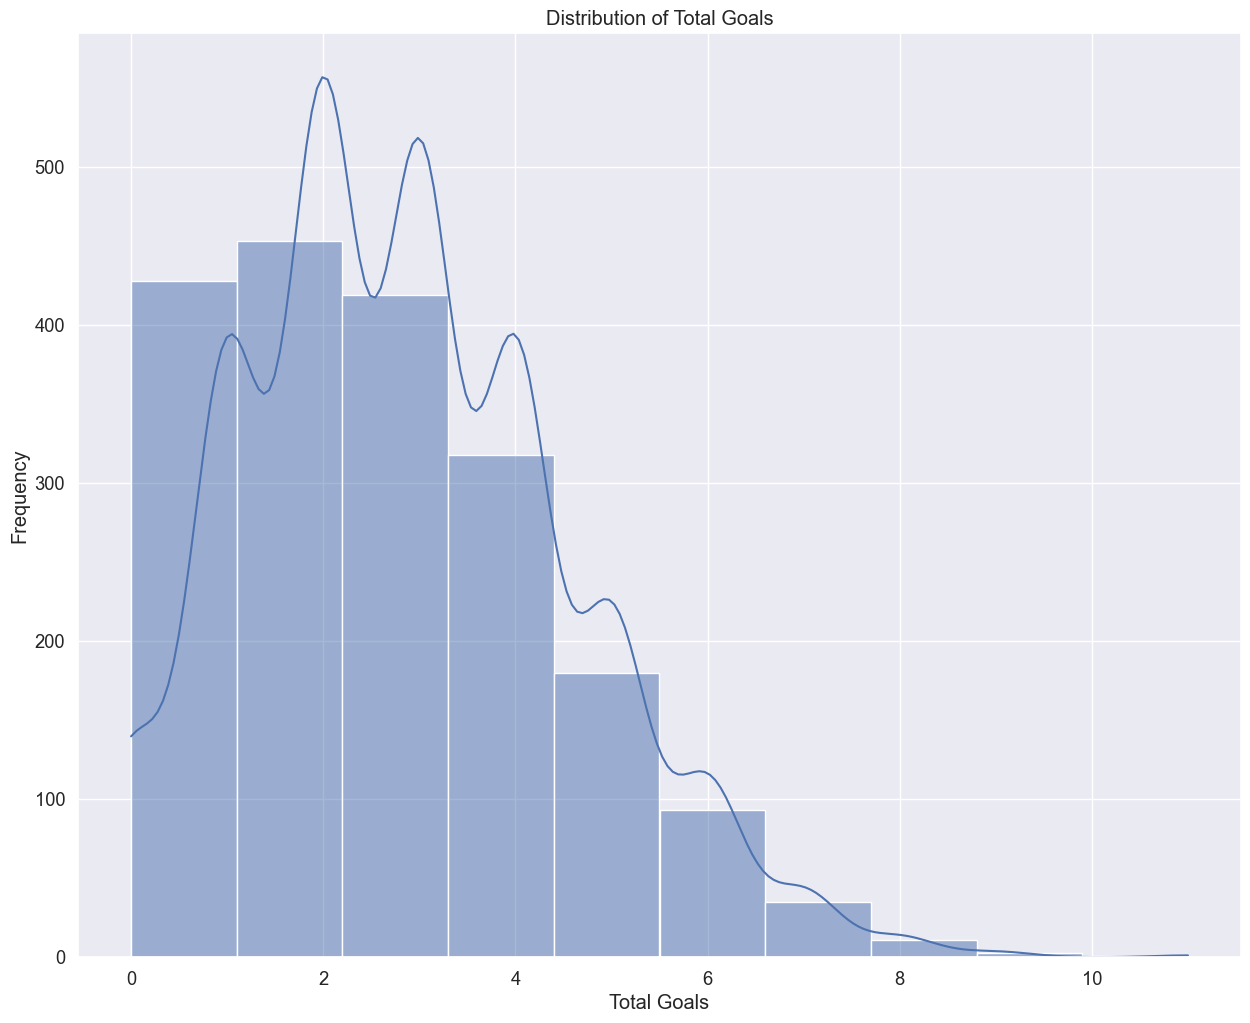

In [45]:
#E
print('\nВизуализация')
sns.histplot(df['total_goals'], kde=True, bins=10)
plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

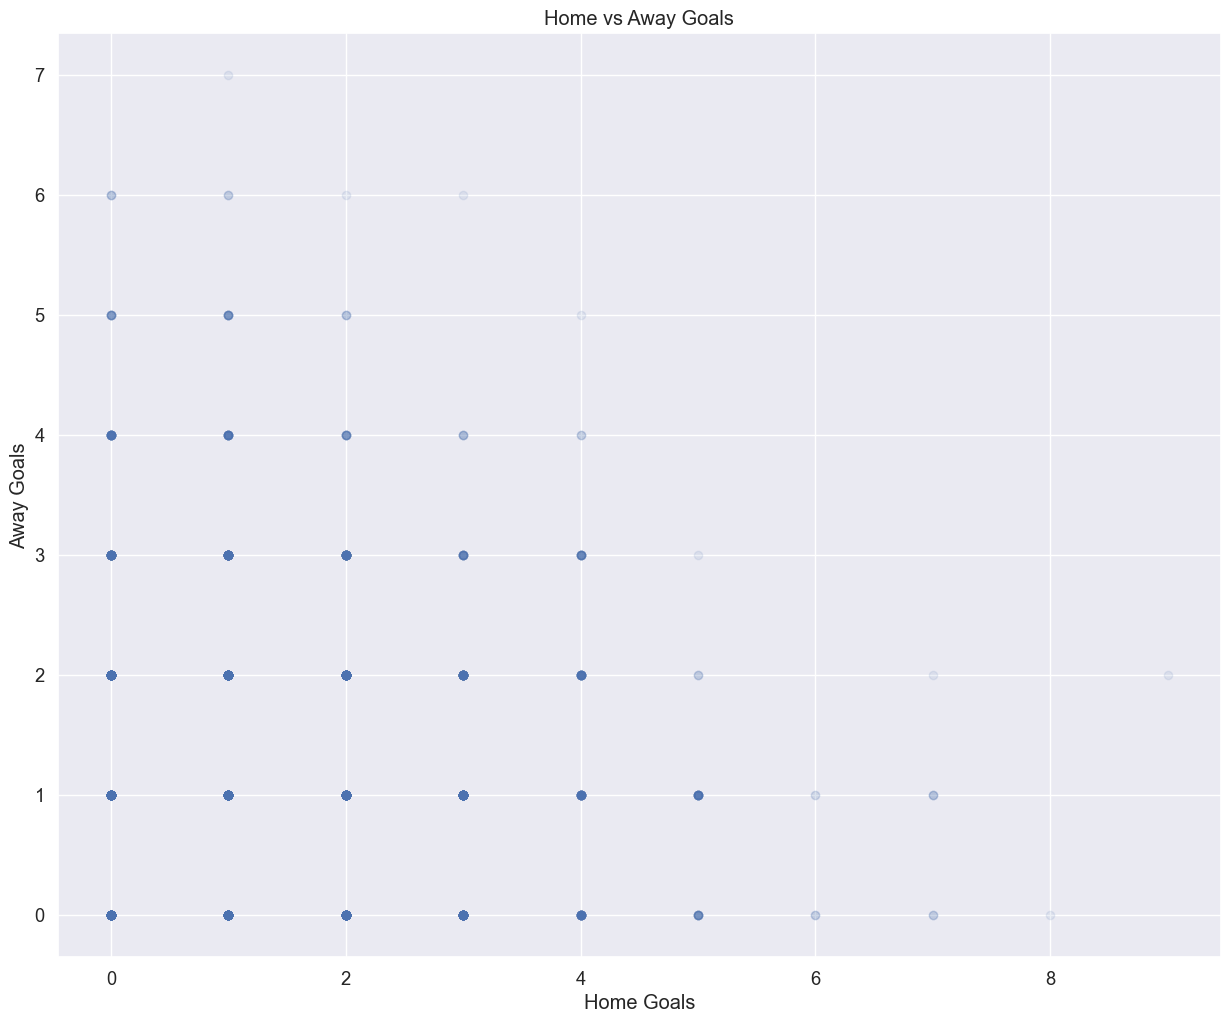

In [46]:
plt.scatter(df['fulltime_home'], df['fulltime_away'], alpha=0.1)
plt.xlabel("Home Goals")
plt.ylabel("Away Goals")
plt.title("Home vs Away Goals")
plt.show()

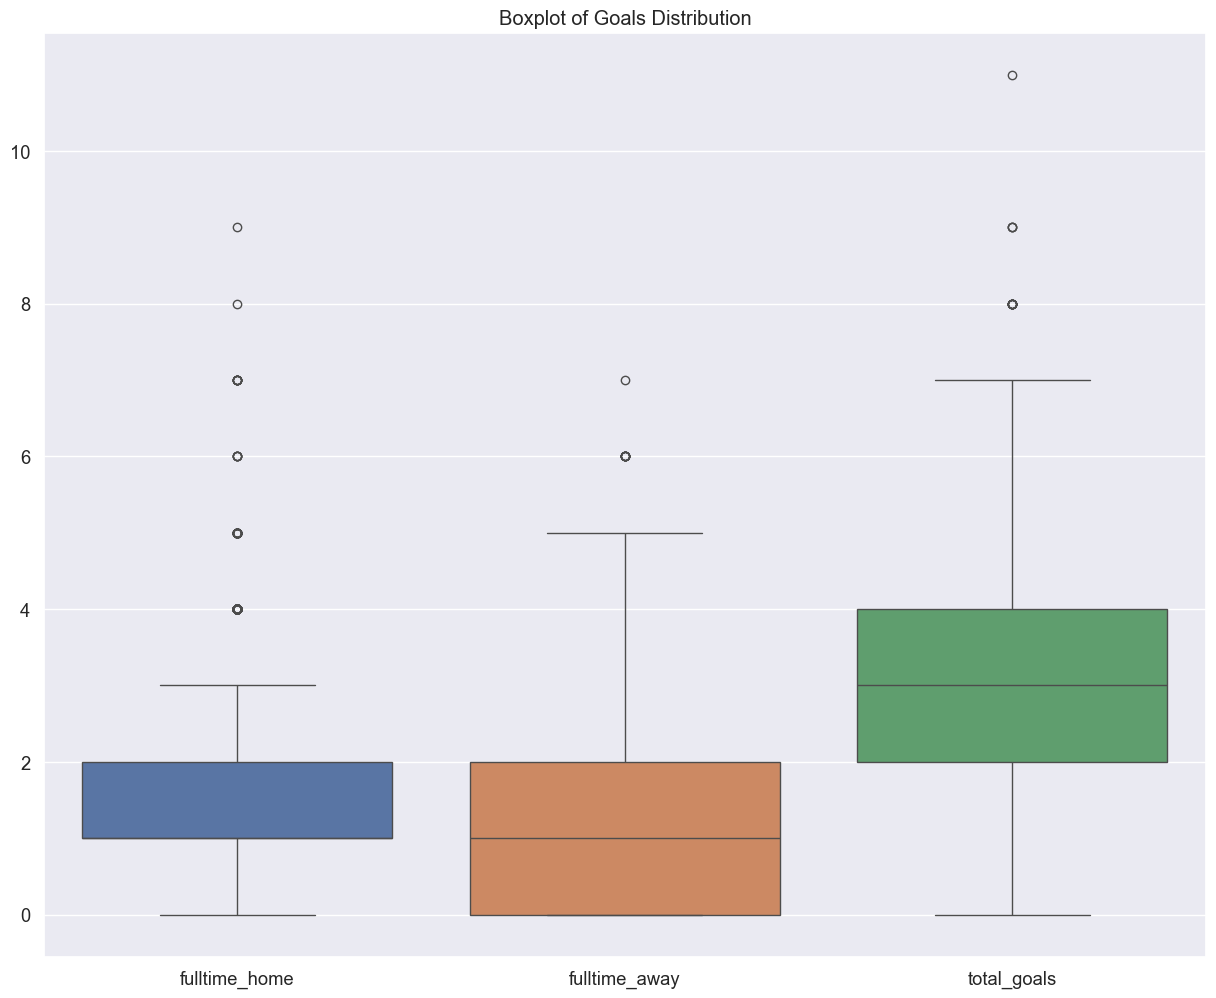

In [47]:
sns.boxplot(data=df[['fulltime_home','fulltime_away','total_goals']])
plt.title("Boxplot of Goals Distribution")
plt.show()

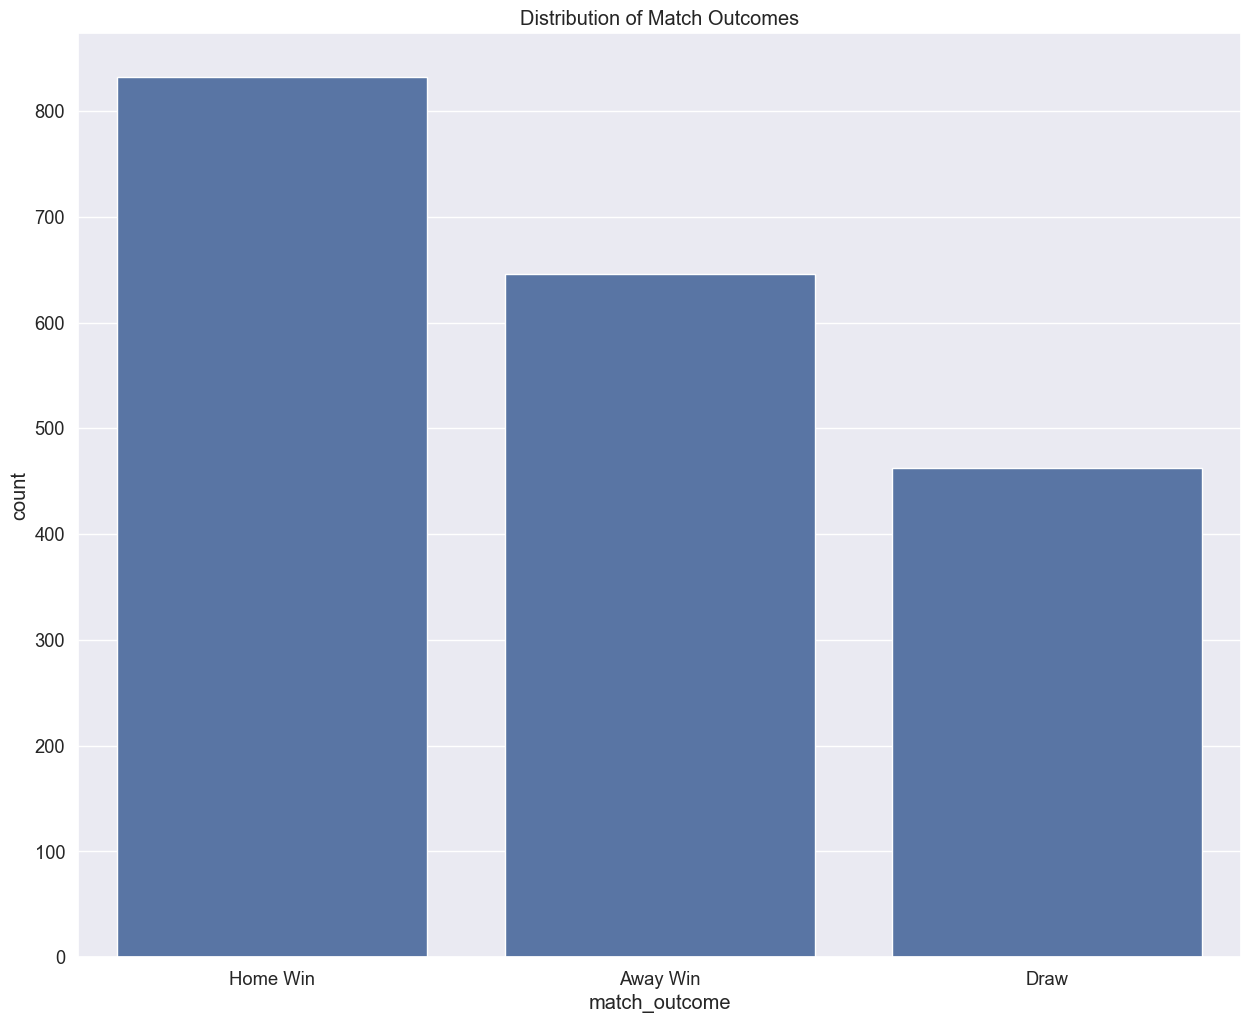

In [48]:
sns.countplot(x='match_outcome', data=df)
plt.title("Distribution of Match Outcomes")
plt.show()

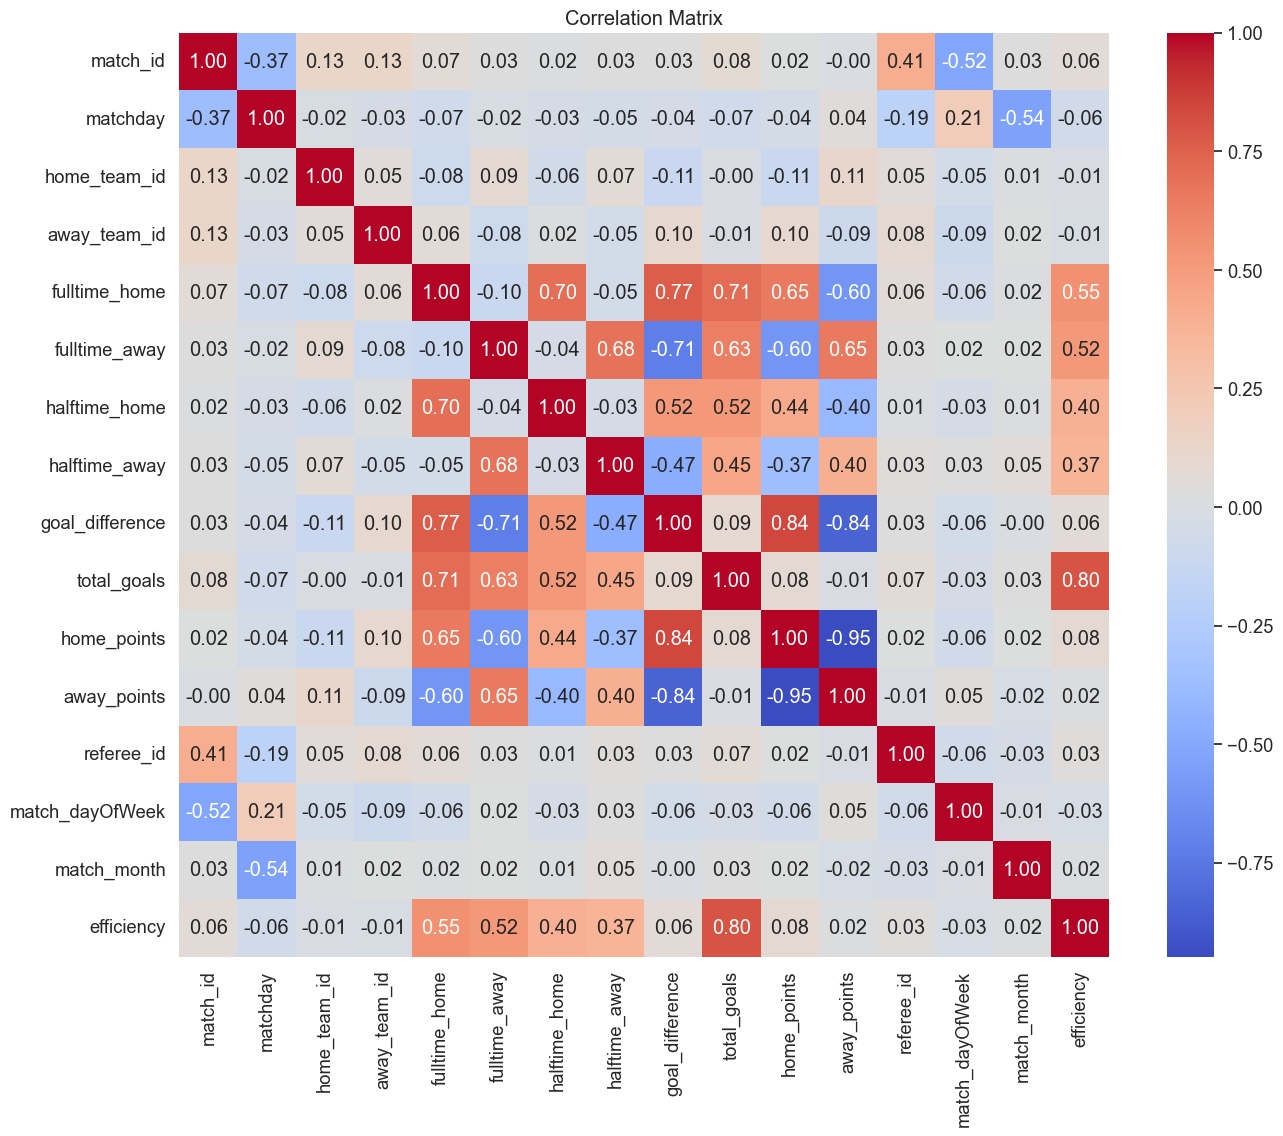

In [49]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [50]:
fig = px.scatter(
    df,
    x='fulltime_home',
    y='fulltime_away',
    color='match_outcome',
    title='Interactive Scatter Plot of Match Goals',
    opacity=0.1
)
fig.show()

In [51]:
fig = px.histogram(
    df,
    x='total_goals',
    nbins=10,
    title="Distribution of Total Goals"
)
fig.show()

In [52]:
#F
#Я разобрался с основными методами обзора данных(df.head(), df.tail(), df.shape, df.info() и df.describe()). Понял в каких случаях стоит использовать dropna(), fillna(), когда пропуски нужно заполнять средним, медианным, константным значениями, а когда mode. Разобрался со статистикой числовых данных. Ознакомился со способами кодирования категорий(OneHotEncoder, Label Encoding, Target Encoding, Feature Hashing), хоть еще не до конца разобрался в чем различие между последними тремя(смысл понятен, а когда использовать не до конца). Сделал визуализацию для данных.

#Наблюдения из полученных данных: Некоторые команды могут играть более результативно, что может быть выявлено через target encoding команд; победа домашней команды происходит чаще.
#Гипотезы: команды, которые часто побеждают дома, могут иметь более высокую среднюю результативность на домашнем стадионе; матчи между сильными командами могут иметь более низкую результативность, так как команды играют осторожнее; в матчах с большим количеством голов часто наблюдается большая разница в уровне команд.

#Дальше я бы исследовал уровень команд, например по среднему количеству голов, можно рассмотреть детальнее и взять средние на домашнем и чужом стадионах, и на основе этого предсказывать результативность матча и исход, сравнивая также уровни команд, против которых команды-соперники уже играли.

#Помощь искусственного интеллекта. ChatGPT помогал мне с синтаксисом, потому что я им пока что не очень хорошо владею. Также там я прочитал про виды кодирования и параметры(?) для статистики числовых колонок